## Assignment 7 Pandas Fundamentals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"
df = pd.read_csv(url)

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  float64
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  id         120108 non-null  object 
 12  updated    120108 non-null  object 
 13  place      120108 non-null  object 
 14  type       120108 non-null  object 
dtypes: float64(8), object(7)
memory usage: 13.7+ MB


In [3]:
df = pd.read_csv(
    url,
    parse_dates=["time", "updated"],
    index_col="id"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       120108 non-null  datetime64[ns]     
 1   latitude   120108 non-null  float64            
 2   longitude  120108 non-null  float64            
 3   depth      120107 non-null  float64            
 4   mag        120065 non-null  float64            
 5   magType    120065 non-null  object             
 6   nst        59688 non-null   float64            
 7   gap        94935 non-null   float64            
 8   dmin       85682 non-null   float64            
 9   rms        119716 non-null  float64            
 10  net        120108 non-null  object             
 11  updated    120108 non-null  datetime64[ns, UTC]
 12  place      120108 non-null  object             
 13  type       120108 non-null  object             
dtypes: datetime64[ns, UTC](1), d

In [4]:
max_id = df["mag"].idxmax()
max_id

'usc000nzvd'

In [5]:
df.loc[max_id]

time               2014-04-01 23:46:47.260000
latitude                             -19.6097
longitude                            -70.7691
depth                                    25.0
mag                                       8.2
magType                                   mww
nst                                       NaN
gap                                      23.0
dmin                                    0.609
rms                                      0.66
net                                        us
updated      2015-07-30 16:24:51.223000+00:00
place               94km NW of Iquique, Chile
type                               earthquake
Name: usc000nzvd, dtype: object

In [6]:
df["sig"] = df["mag"] > 5
df["sig"].head()

id
ak11155107    False
nn00436847    False
ak11151142    False
ak11151135    False
ci37171541    False
Name: sig, dtype: bool

In [7]:
df["sig"].sum()

1348

In [8]:
bins = [0, 70, 300, 700]
labels = ["0-70 km", "70-300 km", "300-700 km"]

df["depth_cat"] = pd.cut(df["depth"], bins=bins, labels=labels)

df[["depth", "depth_cat"]].head()

,depth,depth_cat
id,,
ak11155107,90.20,70-300 km
nn00436847,0.00,NaN
ak11151142,7.10,0-70 km
ak11151135,96.50,70-300 km
ci37171541,10.59,0-70 km


In [9]:
df.groupby("depth_cat")["sig"].sum()

/tmp/ipykernel_363953/3959021950.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("depth_cat")["sig"].sum()


depth_cat
0-70 km       1118
70-300 km      182
300-700 km      46
Name: sig, dtype: int64

In [10]:
df["month"] = df["time"].dt.month
df["month"].head()

id
ak11155107    1
nn00436847    1
ak11151142    1
ak11151135    1
ci37171541    1
Name: month, dtype: int32

In [11]:
df["month"].value_counts().sort_index()

month
1      9238
2      8806
3      9493
4     10153
5      9708
6     10309
7     10946
8     10016
9     11416
10    10289
11    10880
12     8854
Name: count, dtype: int64

In [12]:
filtered = df[(df["mag"] > 5) & (df["depth"] < 70)]
filtered.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,sig,depth_cat,month
id,,,,,,,,,,,,,,,,,
usc000mcu0,2014-01-29 13:46:50.340,23.8428,93.9581,59.11,5.1,mb,NaN,19.0,2.425,0.68,us,2014-04-08 01:43:15+00:00,"52km WNW of Mawlaik, Burma",earthquake,True,0-70 km,1
usc000mcj6,2014-01-29 00:32:28.240,-9.5949,161.2282,41.00,5.6,mwb,NaN,16.0,1.272,0.70,us,2014-04-08 01:43:14+00:00,"108km SSE of Auki, Solomon Islands",earthquake,True,0-70 km,1
usc000mcfd,2014-01-28 22:22:14.890,56.7401,-34.5072,10.00,5.3,mwb,NaN,24.0,7.171,1.24,us,2014-03-27 18:15:46+00:00,Reykjanes Ridge,earthquake,True,0-70 km,1
usb000m8wn,2014-01-27 16:31:09.390,-11.8278,165.2389,14.14,5.3,mb,NaN,91.0,4.072,0.58,us,2014-03-27 18:15:44+00:00,"138km SSW of Lata, Solomon Islands",earthquake,True,0-70 km,1
usb000m8mw,2014-01-27 02:36:35.210,-4.3923,153.0963,39.93,5.1,mb,NaN,38.0,0.951,0.99,us,2014-03-27 18:15:43+00:00,"10km NE of Taron, Papua New Guinea",earthquake,True,0-70 km,1


In [13]:
pivot = df.pivot_table(
    values="mag",
    index="month",
    columns="depth_cat",
    aggfunc="mean"
)

pivot

/tmp/ipykernel_363953/471078383.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


depth_cat,0-70 km,70-300 km,300-700 km
month,,,
1,1.706038,2.675048,4.381739
2,1.493313,2.687133,4.405814
3,1.738732,2.430089,4.492308
4,1.913928,2.344164,4.437113
5,1.682035,2.451248,4.412598
6,1.764654,2.682846,4.372917
7,1.614524,2.720679,4.405455
8,1.657399,2.703992,4.405941
9,1.465363,2.673947,4.389623


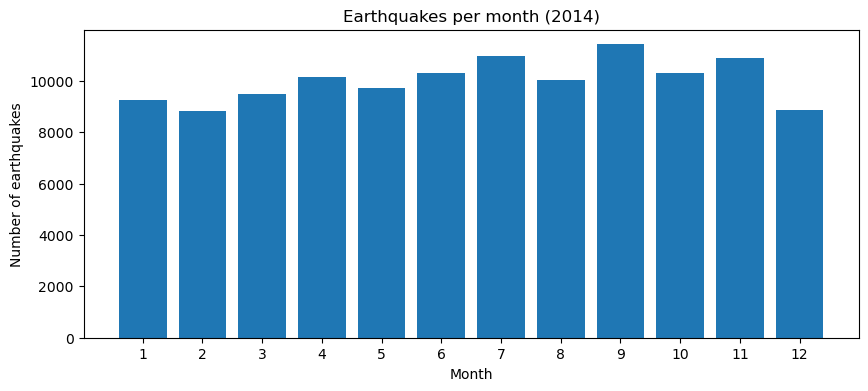

In [14]:
monthly_counts = df["month"].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.bar(monthly_counts.index, monthly_counts.values)
plt.xlabel("Month")
plt.ylabel("Number of earthquakes")
plt.title("Earthquakes per month (2014)")
plt.xticks(monthly_counts.index)
plt.show()